#IMPORT LIBRARY

In [ ]:
# =========================================================
# IMPORT LIBRARY
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from google.colab import files

# =========================================================
# LOAD DATASET
# =========================================================

df = pd.read_csv('/content/student_mental_health_burnout.csv')

# menghapus spasi tersembunyi
df.columns = df.columns.str.strip()

print("Jumlah Data :", df.shape)

print("\n5 Data Pertama")
display(df.head())

# =========================================================
# INFORMASI DATASET
# =========================================================

print(df.info())

print("\nNama Kolom Dataset")
print(df.columns.tolist())

print("\nMissing Value")
print(df.isnull().sum())

Jumlah Data : (150000, 20)

5 Data Pertama


,student_id,age,gender,course,year,daily_study_hours,daily_sleep_hours,screen_time_hours,stress_level,anxiety_score,depression_score,academic_pressure_score,financial_stress_score,social_support_score,physical_activity_hours,sleep_quality,attendance_percentage,cgpa,internet_quality,burnout_level
0,100001,23,Male,BTech,1st,4.3,6.8,6.1,High,10,3,4,2,6,1.8,Average,66.5,9.63,Good,High
1,100002,20,Male,BTech,3rd,1.4,4.7,3.0,High,2,10,8,5,9,1.9,Poor,55.8,6.04,Poor,Low
2,100003,24,Female,BCA,4th,3.7,4.8,1.5,Low,2,7,8,6,3,0.8,Good,85.0,8.31,Good,High
3,100004,21,Male,BSc,4th,1.6,6.7,7.0,High,3,3,4,9,9,0.7,Poor,89.1,5.95,Good,High
4,100005,23,Other,BSc,4th,2.0,6.7,5.4,High,7,7,6,4,4,1.7,Good,58.7,8.51,Good,Low


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 20 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   student_id               150000 non-null  int64  
 1   age                      150000 non-null  int64  
 2   gender                   150000 non-null  object 
 3   course                   150000 non-null  object 
 4   year                     150000 non-null  object 
 5   daily_study_hours        150000 non-null  float64
 6   daily_sleep_hours        150000 non-null  float64
 7   screen_time_hours        150000 non-null  float64
 8   stress_level             150000 non-null  object 
 9   anxiety_score            150000 non-null  int64  
 10  depression_score         150000 non-null  int64  
 11  academic_pressure_score  150000 non-null  int64  
 12  financial_stress_score   150000 non-null  int64  
 13  social_support_score     150000 non-null  int64  
 14  phys

#PREPROCESING

In [ ]:
# =========================================================
# PREPROCESSING DATA
# =========================================================

print("\n================ PREPROCESSING DATA ================\n")

# 1. Hapus data duplikat
df = df.drop_duplicates()

# 2. Menangani missing value
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].mean())

categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("\nPreprocessing selesai")
display(df.head())


================ PREPROCESSING DATA ================


Preprocessing selesai


,student_id,age,gender,course,year,daily_study_hours,daily_sleep_hours,screen_time_hours,stress_level,anxiety_score,depression_score,academic_pressure_score,financial_stress_score,social_support_score,physical_activity_hours,sleep_quality,attendance_percentage,cgpa,internet_quality,burnout_level
0,100001,23,Male,BTech,1st,4.3,6.8,6.1,High,10,3,4,2,6,1.8,Average,66.5,9.63,Good,High
1,100002,20,Male,BTech,3rd,1.4,4.7,3.0,High,2,10,8,5,9,1.9,Poor,55.8,6.04,Poor,Low
2,100003,24,Female,BCA,4th,3.7,4.8,1.5,Low,2,7,8,6,3,0.8,Good,85.0,8.31,Good,High
3,100004,21,Male,BSc,4th,1.6,6.7,7.0,High,3,3,4,9,9,0.7,Poor,89.1,5.95,Good,High
4,100005,23,Other,BSc,4th,2.0,6.7,5.4,High,7,7,6,4,4,1.7,Good,58.7,8.51,Good,Low


#MENAMBAH VARIABEL BARU

In [ ]:
# =========================================================
# MENAMBAHKAN VARIABEL BARU
# =========================================================

# agar hasil random tetap sama
np.random.seed(42)

# =========================================================
# CODING HOURS PER DAY
# =========================================================

df['coding_hours_per_day'] = np.random.uniform(
    1,
    10,
    size=len(df)
)

# =========================================================
# ASSIGNMENT DEADLINE PRESSURE
# =========================================================

df['assignment_deadline_pressure'] = np.random.randint(
    1,
    11,
    size=len(df)
)

display(
    df[[
        'coding_hours_per_day',
        'assignment_deadline_pressure'
    ]].head()
)

,coding_hours_per_day,assignment_deadline_pressure
0,4.370861,3
1,9.556429,6
2,7.587945,2
3,6.387926,8
4,2.404168,4


#KONVERSI DATA KATEGORI

#Konversi Stress Level

In [ ]:
# =========================================================
# KONVERSI STRESS LEVEL
# =========================================================

stress_mapping = {
    'Low': 1,
    'Medium': 2,
    'High': 3
}

df['stress_level_num'] = (
    df['stress_level']
    .map(stress_mapping)
)

display(
    df[[
        'stress_level',
        'stress_level_num'
    ]].head()
)

,stress_level,stress_level_num
0,High,3
1,High,3
2,Low,1
3,High,3
4,High,3


#Konversi Sleep Quality

In [ ]:
# =========================================================
# KONVERSI SLEEP QUALITY
# =========================================================

print(df['sleep_quality'].unique())

# =========================================================
# MAPPING SLEEP QUALITY
# =========================================================

sleep_mapping = {
    'Poor': 1,
    'Average': 2,
    'Good': 3
}

df['sleep_quality_num'] = (
    df['sleep_quality']
    .map(sleep_mapping)
)

display(
    df[[
        'sleep_quality',
        'sleep_quality_num'
    ]].head()
)

['Average' 'Poor' 'Good']


,sleep_quality,sleep_quality_num
0,Average,2
1,Poor,1
2,Good,3
3,Poor,1
4,Good,3


#DEFINISI KRITERIA DAN DATA

In [ ]:
# =========================================================
# STEP 1 — DEFINISI KRITERIA & DATA
# =========================================================

criteria = [
    'C1 (Stress Level)', 'C2 (Anxiety Score)', 'C3 (Depression Score)',
    'C4 (Academic Pressure)', 'C5 (Social Support)', 'C6 (Screen Time)',
    'C7 (Sleep Quality)', 'C8 (Daily Sleep Hours)',
    'C9 (Coding Hours)', 'C10 (Assignment Deadline)'
]

types = ['Cost','Cost','Cost','Cost','Benefit','Cost','Benefit','Benefit','Benefit','Cost']

weights = np.array([0.10]*10)
print("Total Bobot =", weights.sum())

# --- 1a. Tabel Kriteria, Aturan, dan Bobot ---
df_kriteria = pd.DataFrame({
    'Kriteria': criteria,
    'Tipe': types,
    'Bobot': weights
})
print("\n--- 1a. Tabel Kriteria, Aturan, dan Bobot ---")
display(df_kriteria)

# --- 1b. Tabel Data Mentah ---
kolom_dataset = [
    'stress_level_num', 'anxiety_score', 'depression_score',
    'academic_pressure_score', 'social_support_score', 'screen_time_hours',
    'sleep_quality_num', 'daily_sleep_hours',
    'coding_hours_per_day', 'assignment_deadline_pressure'
]

student_ids = df['student_id'].head(10).values
alternatives = [f"{sid} (A{i+1})" for i, sid in enumerate(student_ids)]

df_X = pd.DataFrame(
    df[kolom_dataset].head(10).values,
    index=alternatives,
    columns=criteria
)
print("\n--- 1b. Tabel Data Mentah ---")
display(df_X)


Total Bobot = 1.0

--- 1a. Tabel Kriteria, Aturan, dan Bobot ---


,Kriteria,Tipe,Bobot
0,C1 (Stress Level),Cost,0.1
1,C2 (Anxiety Score),Cost,0.1
2,C3 (Depression Score),Cost,0.1
3,C4 (Academic Pressure),Cost,0.1
4,C5 (Social Support),Benefit,0.1
5,C6 (Screen Time),Cost,0.1
6,C7 (Sleep Quality),Benefit,0.1
7,C8 (Daily Sleep Hours),Benefit,0.1
8,C9 (Coding Hours),Benefit,0.1
9,C10 (Assignment Deadline),Cost,0.1



--- 1b. Tabel Data Mentah ---


,C1 (Stress Level),C2 (Anxiety Score),C3 (Depression Score),C4 (Academic Pressure),C5 (Social Support),C6 (Screen Time),C7 (Sleep Quality),C8 (Daily Sleep Hours),C9 (Coding Hours),C10 (Assignment Deadline)
100001 (A1),3.0,10.0,3.0,4.0,6.0,6.1,2.0,6.8,4.370861,3.0
100002 (A2),3.0,2.0,10.0,8.0,9.0,3.0,1.0,4.7,9.556429,6.0
100003 (A3),1.0,2.0,7.0,8.0,3.0,1.5,3.0,4.8,7.587945,2.0
100004 (A4),3.0,3.0,3.0,4.0,9.0,7.0,1.0,6.7,6.387926,8.0
100005 (A5),3.0,7.0,7.0,6.0,4.0,5.4,3.0,6.7,2.404168,4.0
100006 (A6),3.0,8.0,4.0,9.0,2.0,4.1,1.0,4.8,2.403951,10.0
100007 (A7),1.0,5.0,9.0,9.0,6.0,7.8,2.0,8.0,1.522753,8.0
100008 (A8),2.0,5.0,10.0,3.0,6.0,7.6,1.0,6.3,8.795585,8.0
100009 (A9),1.0,1.0,1.0,7.0,1.0,1.3,2.0,5.4,6.410035,8.0
100010 (A10),2.0,4.0,2.0,4.0,7.0,11.5,1.0,7.0,7.372653,1.0


#AVERAGE SOLUTION

In [ ]:
# =========================================================
# STEP 2 — AVERAGE SOLUTION (AV)
# =========================================================

AV = df_X.mean()

print("\n--- 2. Average Solution (AV) ---")
display(pd.DataFrame(AV, columns=['Nilai Rata-rata (AV)']).T)


--- 2. Average Solution (AV) ---


,C1 (Stress Level),C2 (Anxiety Score),C3 (Depression Score),C4 (Academic Pressure),C5 (Social Support),C6 (Screen Time),C7 (Sleep Quality),C8 (Daily Sleep Hours),C9 (Coding Hours),C10 (Assignment Deadline)
Nilai Rata-rata (AV),2.2,4.7,5.6,6.2,5.3,5.53,1.7,6.12,5.681231,5.8


#PDA DAN NDA

In [ ]:
# =========================================================
# STEP 3 — PDA DAN NDA
# =========================================================

PDA = pd.DataFrame(np.zeros(df_X.shape), index=alternatives, columns=criteria)
NDA = pd.DataFrame(np.zeros(df_X.shape), index=alternatives, columns=criteria)

for j, c in enumerate(criteria):
    if types[j].lower() == 'benefit':
        PDA[c] = np.maximum(0, (df_X[c] - AV[c])) / AV[c]
        NDA[c] = np.maximum(0, (AV[c] - df_X[c])) / AV[c]
    elif types[j].lower() == 'cost':
        PDA[c] = np.maximum(0, (AV[c] - df_X[c])) / AV[c]
        NDA[c] = np.maximum(0, (df_X[c] - AV[c])) / AV[c]

print("\n--- 3a. Positive Distance from Average (PDA) ---")
display(PDA)
print("\n--- 3b. Negative Distance from Average (NDA) ---")
display(NDA)


--- 3a. Positive Distance from Average (PDA) ---


,C1 (Stress Level),C2 (Anxiety Score),C3 (Depression Score),C4 (Academic Pressure),C5 (Social Support),C6 (Screen Time),C7 (Sleep Quality),C8 (Daily Sleep Hours),C9 (Coding Hours),C10 (Assignment Deadline)
100001 (A1),0.000000,0.000000,0.464286,0.354839,0.132075,0.000000,0.176471,0.111111,0.000000,0.482759
100002 (A2),0.000000,0.574468,0.000000,0.000000,0.698113,0.457505,0.000000,0.000000,0.682105,0.000000
100003 (A3),0.545455,0.574468,0.000000,0.000000,0.000000,0.728752,0.764706,0.000000,0.335617,0.655172
100004 (A4),0.000000,0.361702,0.464286,0.354839,0.698113,0.000000,0.000000,0.094771,0.124391,0.000000
100005 (A5),0.000000,0.000000,0.000000,0.032258,0.000000,0.023508,0.764706,0.094771,0.000000,0.310345
100006 (A6),0.000000,0.000000,0.285714,0.000000,0.000000,0.258590,0.000000,0.000000,0.000000,0.000000
100007 (A7),0.545455,0.000000,0.000000,0.000000,0.132075,0.000000,0.176471,0.307190,0.000000,0.000000
100008 (A8),0.090909,0.000000,0.000000,0.516129,0.132075,0.000000,0.000000,0.029412,0.548183,0.000000
100009 (A9),0.545455,0.787234,0.821429,0.000000,0.000000,0.764919,0.176471,0.000000,0.128283,0.000000
100010 (A10),0.090909,0.148936,0.642857,0.354839,0.320755,0.000000,0.000000,0.143791,0.297721,0.827586



--- 3b. Negative Distance from Average (NDA) ---


,C1 (Stress Level),C2 (Anxiety Score),C3 (Depression Score),C4 (Academic Pressure),C5 (Social Support),C6 (Screen Time),C7 (Sleep Quality),C8 (Daily Sleep Hours),C9 (Coding Hours),C10 (Assignment Deadline)
100001 (A1),0.363636,1.127660,0.000000,0.000000,0.000000,0.103074,0.000000,0.000000,0.230649,0.000000
100002 (A2),0.363636,0.000000,0.785714,0.290323,0.000000,0.000000,0.411765,0.232026,0.000000,0.034483
100003 (A3),0.000000,0.000000,0.250000,0.290323,0.433962,0.000000,0.000000,0.215686,0.000000,0.000000
100004 (A4),0.363636,0.000000,0.000000,0.000000,0.000000,0.265823,0.411765,0.000000,0.000000,0.379310
100005 (A5),0.363636,0.489362,0.250000,0.000000,0.245283,0.000000,0.000000,0.000000,0.576823,0.000000
100006 (A6),0.363636,0.702128,0.000000,0.451613,0.622642,0.000000,0.411765,0.215686,0.576861,0.724138
100007 (A7),0.000000,0.063830,0.607143,0.451613,0.000000,0.410488,0.000000,0.000000,0.731968,0.379310
100008 (A8),0.000000,0.063830,0.785714,0.000000,0.000000,0.374322,0.411765,0.000000,0.000000,0.379310
100009 (A9),0.000000,0.000000,0.000000,0.129032,0.811321,0.000000,0.000000,0.117647,0.000000,0.379310
100010 (A10),0.000000,0.000000,0.000000,0.000000,0.000000,1.079566,0.411765,0.000000,0.000000,0.000000


#SP DAN SN

In [ ]:
# =========================================================
# STEP 4 — SP DAN SN
# =========================================================

SP = (PDA * weights).sum(axis=1)
SN = (NDA * weights).sum(axis=1)

df_S = pd.DataFrame({'SP (Sum of PDA)': SP, 'SN (Sum of NDA)': SN})
print("\n--- 4. Jumlah Terbobot SP & SN ---")
display(df_S)


--- 4. Jumlah Terbobot SP & SN ---


,SP (Sum of PDA),SN (Sum of NDA)
100001 (A1),0.172154,0.182502
100002 (A2),0.241219,0.211795
100003 (A3),0.360417,0.118997
100004 (A4),0.209810,0.142053
100005 (A5),0.122559,0.192510
100006 (A6),0.054430,0.406847
100007 (A7),0.116119,0.264435
100008 (A8),0.131671,0.201494
100009 (A9),0.322379,0.143731
100010 (A10),0.282739,0.149133


#NORMALISASI NSP DAN NSN

In [ ]:
# =========================================================
# STEP 5 — NORMALISASI NSP DAN NSN
# =========================================================

NSP = SP / SP.max()
NSN = 1 - (SN / SN.max())

df_NS = pd.DataFrame({'NSP': NSP, 'NSN': NSN})
print("\n--- 5. Normalisasi NSP & NSN ---")
display(df_NS)



--- 5. Normalisasi NSP & NSN ---


,NSP,NSN
100001 (A1),0.477652,0.551424
100002 (A2),0.669278,0.479424
100003 (A3),1.000000,0.707514
100004 (A4),0.582132,0.650843
100005 (A5),0.340047,0.526823
100006 (A6),0.151021,0.000000
100007 (A7),0.322180,0.350037
100008 (A8),0.365329,0.504742
100009 (A9),0.894461,0.646720
100010 (A10),0.784479,0.633442


#APPRAISAL SCORE DAN RANGKING

In [ ]:
# =========================================================
# STEP 6 — APPRAISAL SCORE & RANKING
# =========================================================

AS = 0.5 * (NSP + NSN)

df_final= pd.DataFrame({'Appraisal Score (AS)': AS})
df_final['Peringkat'] = df_final['Appraisal Score (AS)'].rank(ascending=False).astype(int)
df_final = df_final.sort_values(by='Peringkat')

print("\n--- 6. Nilai Skor Penilaian (AS) dan Perangkingan Akhir")
display(df_final)


--- 6. Nilai Skor Penilaian (AS) dan Perangkingan Akhir


,Appraisal Score (AS),Peringkat
100003 (A3),0.853757,1
100009 (A9),0.770590,2
100010 (A10),0.708960,3
100004 (A4),0.616487,4
100002 (A2),0.574351,5
100001 (A1),0.514538,6
100008 (A8),0.435036,7
100005 (A5),0.433435,8
100007 (A7),0.336109,9
100006 (A6),0.075510,10


In [ ]:
# =========================================================
# STEP 6 — APPRAISAL SCORE & RANKING
# =========================================================

AS = 0.5 * (NSP + NSN)

# Gabungkan df_X (data mentah) + AS + Ranking
df_final = df_X.copy()
df_final.index.name = 'Alternatif'
df_final = df_final.reset_index()

df_final['Appraisal Score'] = AS.values
df_final['Ranking'] = pd.Series(AS.values).rank(ascending=False).astype(int).values

# Tambah nomor urut asli dari dataset
df_final.index = df['student_id'].head(10).reset_index()['index']

df_final = df_final.sort_values(by='Ranking')

print("\n=== HASIL AKHIR EDAS ===")
display(df_final)


=== HASIL AKHIR EDAS ===


,Alternatif,C1 (Stress Level),C2 (Anxiety Score),C3 (Depression Score),C4 (Academic Pressure),C5 (Social Support),C6 (Screen Time),C7 (Sleep Quality),C8 (Daily Sleep Hours),C9 (Coding Hours),C10 (Assignment Deadline),Appraisal Score,Ranking
index,,,,,,,,,,,,,
2,100003 (A3),1.0,2.0,7.0,8.0,3.0,1.5,3.0,4.8,7.587945,2.0,0.853757,1
8,100009 (A9),1.0,1.0,1.0,7.0,1.0,1.3,2.0,5.4,6.410035,8.0,0.770590,2
9,100010 (A10),2.0,4.0,2.0,4.0,7.0,11.5,1.0,7.0,7.372653,1.0,0.708960,3
3,100004 (A4),3.0,3.0,3.0,4.0,9.0,7.0,1.0,6.7,6.387926,8.0,0.616487,4
1,100002 (A2),3.0,2.0,10.0,8.0,9.0,3.0,1.0,4.7,9.556429,6.0,0.574351,5
0,100001 (A1),3.0,10.0,3.0,4.0,6.0,6.1,2.0,6.8,4.370861,3.0,0.514538,6
7,100008 (A8),2.0,5.0,10.0,3.0,6.0,7.6,1.0,6.3,8.795585,8.0,0.435036,7
4,100005 (A5),3.0,7.0,7.0,6.0,4.0,5.4,3.0,6.7,2.404168,4.0,0.433435,8
6,100007 (A7),1.0,5.0,9.0,9.0,6.0,7.8,2.0,8.0,1.522753,8.0,0.336109,9


#VISUALISASI EDAS

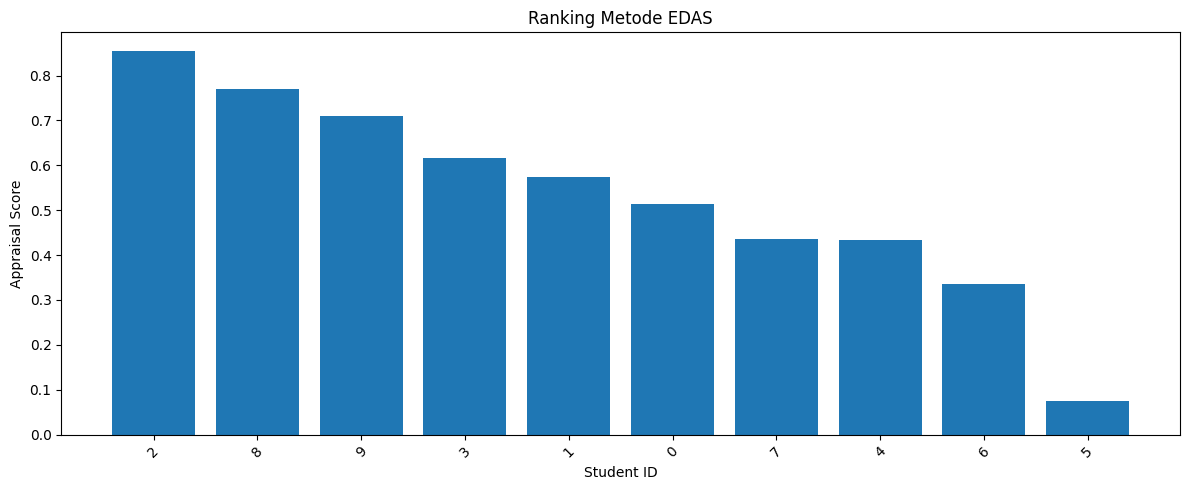

In [ ]:
# =========================================================
# VISUALISASI
# =========================================================

plt.figure(figsize=(12, 5))
plt.bar(df_final.index.astype(str), df_final['Appraisal Score'])
plt.xlabel("Student ID")
plt.ylabel("Appraisal Score")
plt.title("Ranking Metode EDAS")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#Eksport Hasil EDAS ke CSV

In [ ]:
hasil_edas = pd.DataFrame({
    'Alternatif': ranking_edas['Alternatif'],
    'Skor_EDAS': ranking_edas['Appraisal Score'],
    'Ranking_EDAS': ranking_edas['Ranking']
})

hasil_edas = hasil_edas.sort_values('Ranking_EDAS').reset_index(drop=True)

hasil_edas.to_csv('hasil_edas.csv', index=False)

print("Export berhasil!")
print(hasil_edas)

In [ ]:
files.download('hasil_edas.csv')